# Multimodal Conv Benchmark — Evaluation Analysis

7 models · 200 items each · 2 taxonomies · 3 question types

**Step 1**: filter the 68 multiple-choice items missing A/B/C/D options (unanswerable as posed).

In [134]:
import json, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130})

EVAL_DIR = Path('/projects/bfuj/lzhang49/multimodal-conv-bench/eval_results')
MC_OPTION_RE = re.compile(r'\b[A-D][).]')

# Gemma family first (small → large), then Qwen (small → large)
MODEL_ORDER = [
    'gemma-4-E4B-it',
    'gemma-4-26B-A4B-it',
    'gemma-4-31B-it',
    'Qwen3.5-2B',
    'Qwen3.5-4B',
    'Qwen3.5-9B',
    'Qwen3.5-27B',
]
MODEL_COLORS = {
    'gemma-4-E4B-it':      '#f4a261',
    'gemma-4-26B-A4B-it':  '#e06c75',
    'gemma-4-31B-it':      '#922b21',
    'Qwen3.5-2B':          '#aec6e8',
    'Qwen3.5-4B':          '#6baed6',
    'Qwen3.5-9B':          '#3182bd',
    'Qwen3.5-27B':         '#08519c',
}

# ── Load all result files, merging multiple rounds for the same model ──────────
# When evaluations are run taxonomy-by-taxonomy, one model ends up with several
# files (e.g. one for belief_revision, another for cross_turn_entity_tracking).
# Strategy:
#   1. For each (eval_model, taxonomy, idx) keep only the row from the latest file
#      (detected from the YYYYMMDD_HHMMSS timestamp in the filename).
#   2. Remap idx → globally unique integer across all (taxonomy, orig-idx) pairs
#      so every downstream pivot/join still works with a single idx column.

frames = []
for f in sorted(EVAL_DIR.glob('*.jsonl')):
    if 'textonly' in f.name:
        continue
    rows = [json.loads(l) for l in f.open() if l.strip()]
    if not rows:
        continue
    d = pd.DataFrame(rows)
    d['model'] = d['eval_model'].str.split('/').str[-1]
    m = re.search(r'_(\d{8}_\d{6})\.jsonl$', f.name)
    d['_file_ts'] = m.group(1) if m else ''
    frames.append(d)

raw_all = pd.concat(frames, ignore_index=True)

# Keep latest result per (model, taxonomy, original idx)
raw = (
    raw_all
    .sort_values('_file_ts')
    .drop_duplicates(subset=['eval_model', 'taxonomy', 'idx'], keep='last')
    .drop(columns=['_file_ts'])
    .reset_index(drop=True)
)

# Assign a globally unique idx across all (taxonomy, orig-idx) pairs
_key_order = (
    raw[['taxonomy', 'idx']].drop_duplicates()
    .sort_values(['taxonomy', 'idx'])
    .reset_index(drop=True)
)
_key_to_gidx = {(r.taxonomy, r.idx): i for i, r in _key_order.iterrows()}
raw['idx'] = raw.apply(lambda r: _key_to_gidx[(r['taxonomy'], r['idx'])], axis=1)

# Trim MODEL_ORDER to models actually present (avoids reindex NaN rows)
MODEL_ORDER = [m for m in MODEL_ORDER if m in raw['model'].unique()]

n_dupes = len(raw_all) - len(raw)
print(f'Loaded {len(raw_all)} rows from {len(frames)} file(s) → {len(raw)} after dedup'
      + (f' ({n_dupes} duplicate rows dropped)' if n_dupes else ''))
print(f'Models: {raw["model"].nunique()}   Unique items: {raw["idx"].nunique()}')
print()
print(raw.groupby("model")["correct"]
      .agg(["mean", "count"])
      .assign(mean=lambda x: x["mean"] * 100)
      .reindex(MODEL_ORDER)
      .round(1))

Loaded 3283 rows from 28 file(s) → 3283 after dedup
Models: 7   Unique items: 469

                    mean  count
model                          
gemma-4-E4B-it      62.5    469
gemma-4-26B-A4B-it  68.0    469
gemma-4-31B-it      67.4    469
Qwen3.5-2B          62.3    469
Qwen3.5-4B          64.8    469
Qwen3.5-9B          64.2    469
Qwen3.5-27B         61.2    469


## 1. Filter: Remove MC Questions Missing A/B/C/D Options

In [135]:
raw['has_options'] = raw['question'].apply(lambda q: bool(MC_OPTION_RE.search(q or '')))

one = raw[raw['model'] == raw['model'].iloc[0]]
mc_total = (one['question_type'] == 'multiple_choice').sum()
mc_bad   = ((one['question_type'] == 'multiple_choice') & ~one['has_options']).sum()

print(f'Items per model        : {len(one)}')
print(f'Multiple-choice total  : {mc_total}')
print(f'  missing options (BAD): {mc_bad}  → dropped')
print(f'  with options  (GOOD) : {mc_total - mc_bad}  → kept')
print(f'yes_no items           : {(one["question_type"]=="yes_no").sum()}')
print(f'count items            : {(one["question_type"]=="count").sum()}')

df = raw[raw['has_options'] | (raw['question_type'] != 'multiple_choice')].copy()

# Preserve full df for failure-mode breakdown (cell-8 / cell-27), which must
# include format failures in the denominator to be meaningful.
df_all = df.copy()

# TODO: remove the next two lines to re-include format-failure items in accuracy figures.
#       Currently excluded so that accuracy = correct / parseable-items only.
df = df[df['failure_mode'] != 'format_failure'].copy()

N_ITEMS = df['idx'].nunique()
n_fmt   = len(df_all) - len(df)
print(f'\nFinal: {len(df)} rows  ({df["model"].nunique()} models × {N_ITEMS} items)')
print(f'(excluded {n_fmt} format-failure rows from accuracy calculations)')

Items per model        : 469
Multiple-choice total  : 458
  missing options (BAD): 68  → dropped
  with options  (GOOD) : 390  → kept
yes_no items           : 8
count items            : 3

Final: 2675 rows  (7 models × 401 items)
(excluded 132 format-failure rows from accuracy calculations)


In [136]:
dropped = raw[
    (raw['question_type'] == 'multiple_choice') &
    ~raw['has_options'] &
    (raw['model'] == raw['model'].iloc[0])
]
print('Example questions without options (dropped):\n')
for _, r in dropped.head(3).iterrows():
    print(f'  idx={r["idx"]}  [{r["taxonomy"]}]  GT={r["ground_truth"]!r}')
    print(f'  Q: {r["question"][:150]}')
    print()

Example questions without options (dropped):

  idx=396  [temporal_causal_reasoning]  GT='b'
  Q: Based on the sequence of images, which specific visual characteristic present in the earliest stage predicted which cloud would eventually spawn the f

  idx=397  [temporal_causal_reasoning]  GT='b'
  Q: Based on these three images, which statement best describes the causal mechanism for the supercell formation?

  idx=398  [temporal_causal_reasoning]  GT='b'
  Q: Based on the visual progression across these photos, which specific causal chain explains why the storm intensified only on the right side?



## 2. Overall Accuracy by Model

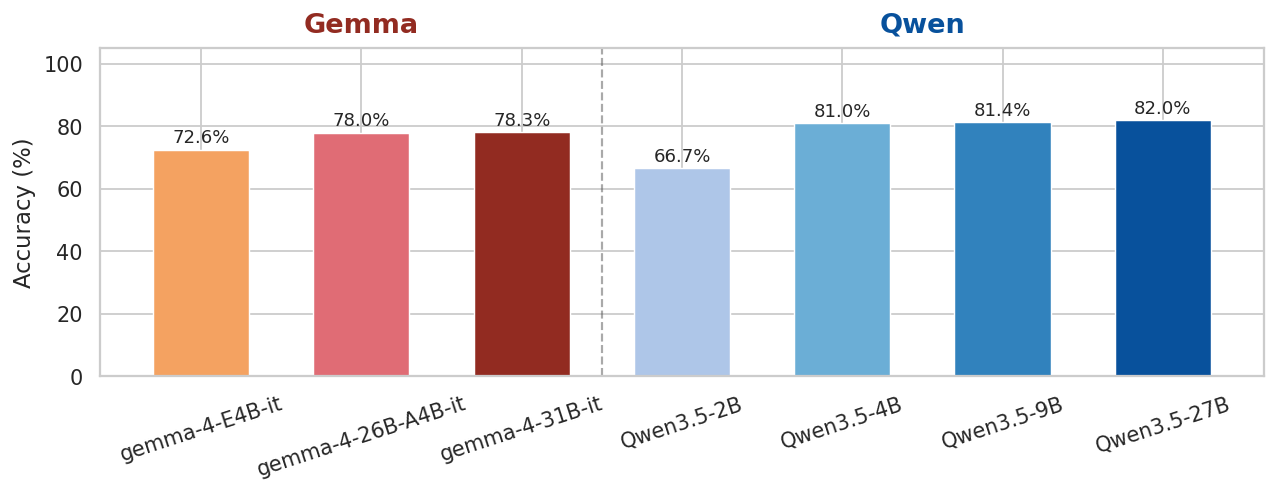

             model  accuracy  n_correct  n_total
    gemma-4-E4B-it 72.568579        291      401
gemma-4-26B-A4B-it 78.000000        312      400
    gemma-4-31B-it 78.304239        314      401
        Qwen3.5-2B 66.666667        266      399
        Qwen3.5-4B 81.043956        295      364
        Qwen3.5-9B 81.369863        297      365
       Qwen3.5-27B 82.028986        283      345


In [137]:
# Add shared columns used throughout
TAX_NAMES = {
    'cross_turn_entity_tracking':  'Cross-Turn Entity Tracking',
    'temporal_causal_reasoning':   'Temporal Causal Reasoning',
    'belief_revision':             'Belief Revision',
    'incremental_state_tracking':  'Incremental State Tracking',
    'interactive_visual_dialogue': 'Interactive Visual Dialogue',
}
# tax_short holds the human-readable full name; unknown taxonomies fall back to title-cased
df['tax_short'] = df['taxonomy'].map(TAX_NAMES).fillna(
    df['taxonomy'].str.replace('_', ' ').str.title()
)
df['family'] = df['model'].apply(lambda m: 'Qwen' if 'Qwen' in m else 'Gemma')

acc = (
    df.groupby('model')['correct']
    .agg(accuracy='mean', n_correct='sum', n_total='count')
    .assign(accuracy=lambda x: x['accuracy'] * 100)
    .reindex(MODEL_ORDER)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [MODEL_COLORS[m] for m in acc['model']]
bars = ax.bar(acc['model'], acc['accuracy'], color=colors, width=0.6, edgecolor='white', linewidth=0.8)
for bar, (_, row) in zip(bars, acc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row['accuracy']:.1f}%",#f"{row['accuracy']:.1f}%\n({int(row['n_correct'])}/{int(row['n_total'])})",
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
# ax.set_title('Overall Accuracy — after filtering invalid MC items', fontweight='bold')
ax.tick_params(axis='x', rotation=18)
ax.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax.text(1.0, 110, 'Gemma', ha='center', fontsize=15, color='#922b21', fontweight='bold')
ax.text(4.5, 110, 'Qwen',  ha='center', fontsize=15, color='#08519c', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_overall_accuracy.png', bbox_inches='tight')
plt.show()
print(acc[['model','accuracy','n_correct','n_total']].to_string(index=False))

## 3. Failure Mode Breakdown

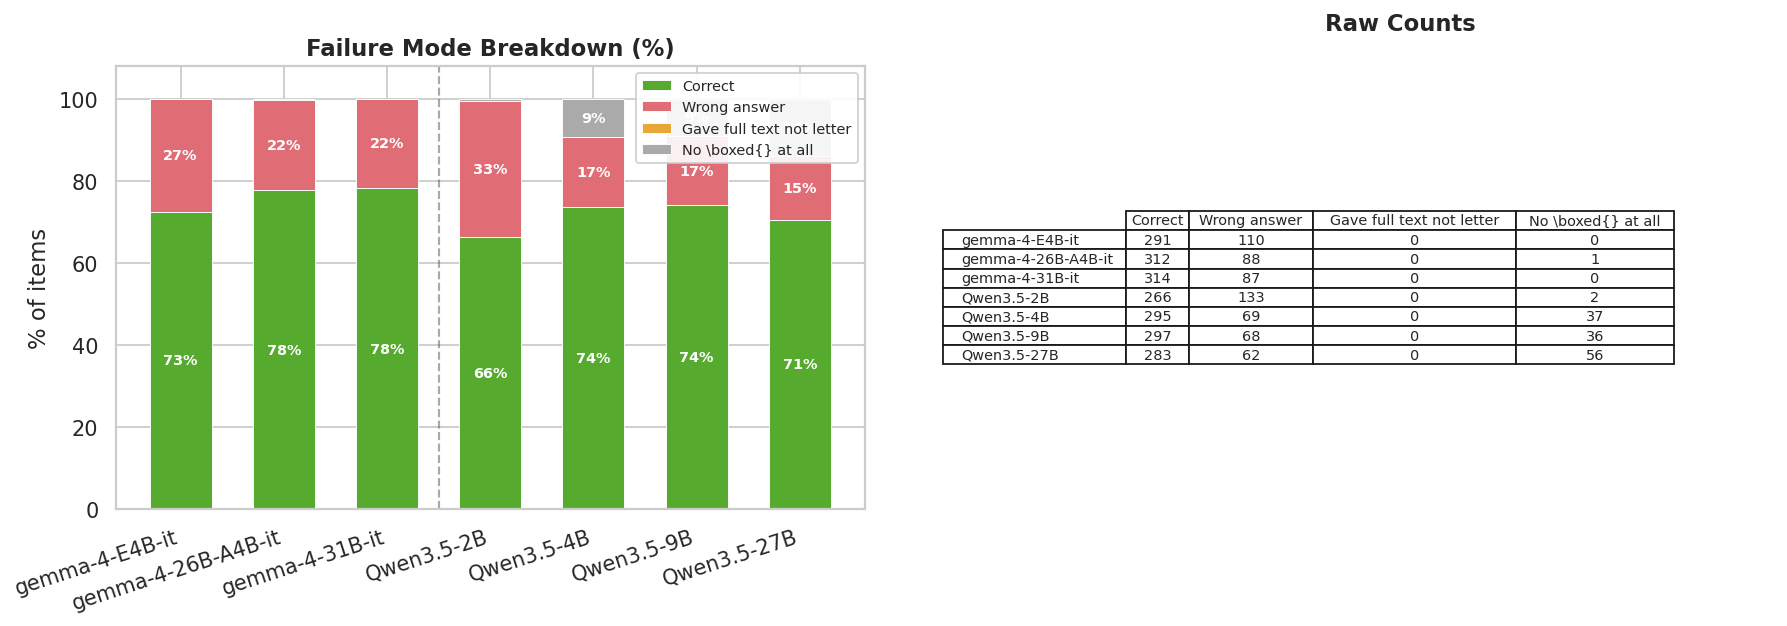

In [138]:
MODES = ['correct', 'wrong_answer', 'option_text_not_letter', 'format_failure']
MODE_COLORS = {'correct': '#56ab2f', 'wrong_answer': '#e06c75',
               'option_text_not_letter': '#e8a838', 'format_failure': '#aaa'}
MODE_LABELS = {'correct': 'Correct', 'wrong_answer': 'Wrong answer',
               'option_text_not_letter': 'Gave full text not letter',
               'format_failure': 'No \\boxed{} at all'}

# Use df_all so format-failure items are included in the denominator here
mode_counts = (
    df_all.groupby(['model', 'failure_mode']).size()
    .unstack('failure_mode').reindex(MODEL_ORDER).fillna(0)
)
mode_pct = (mode_counts.div(mode_counts.sum(axis=1), axis=0) * 100).reindex(columns=MODES, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bottoms = np.zeros(len(mode_pct))
x = np.arange(len(mode_pct))
for mode in MODES:
    vals = mode_pct[mode].values
    ax.bar(x, vals, bottom=bottoms, label=MODE_LABELS[mode],
           color=MODE_COLORS[mode], width=0.6, edgecolor='white', linewidth=0.5)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottoms += vals
ax.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mode_pct.index, rotation=18, ha='right')
ax.set_ylabel('% of items'); ax.set_ylim(0, 108)
ax.set_title('Failure Mode Breakdown (%)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

ax2 = axes[1]
ax2.axis('off')
table_data = mode_counts.reindex(columns=MODES, fill_value=0).astype(int)
table_data.columns = [MODE_LABELS[m] for m in MODES]
t = ax2.table(cellText=table_data.values, rowLabels=table_data.index,
              colLabels=table_data.columns, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(8)
t.auto_set_column_width(col=list(range(len(table_data.columns))))
ax2.set_title('Raw Counts', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig_failure_modes.png', bbox_inches='tight')
plt.show()

## 4. Accuracy by Taxonomy

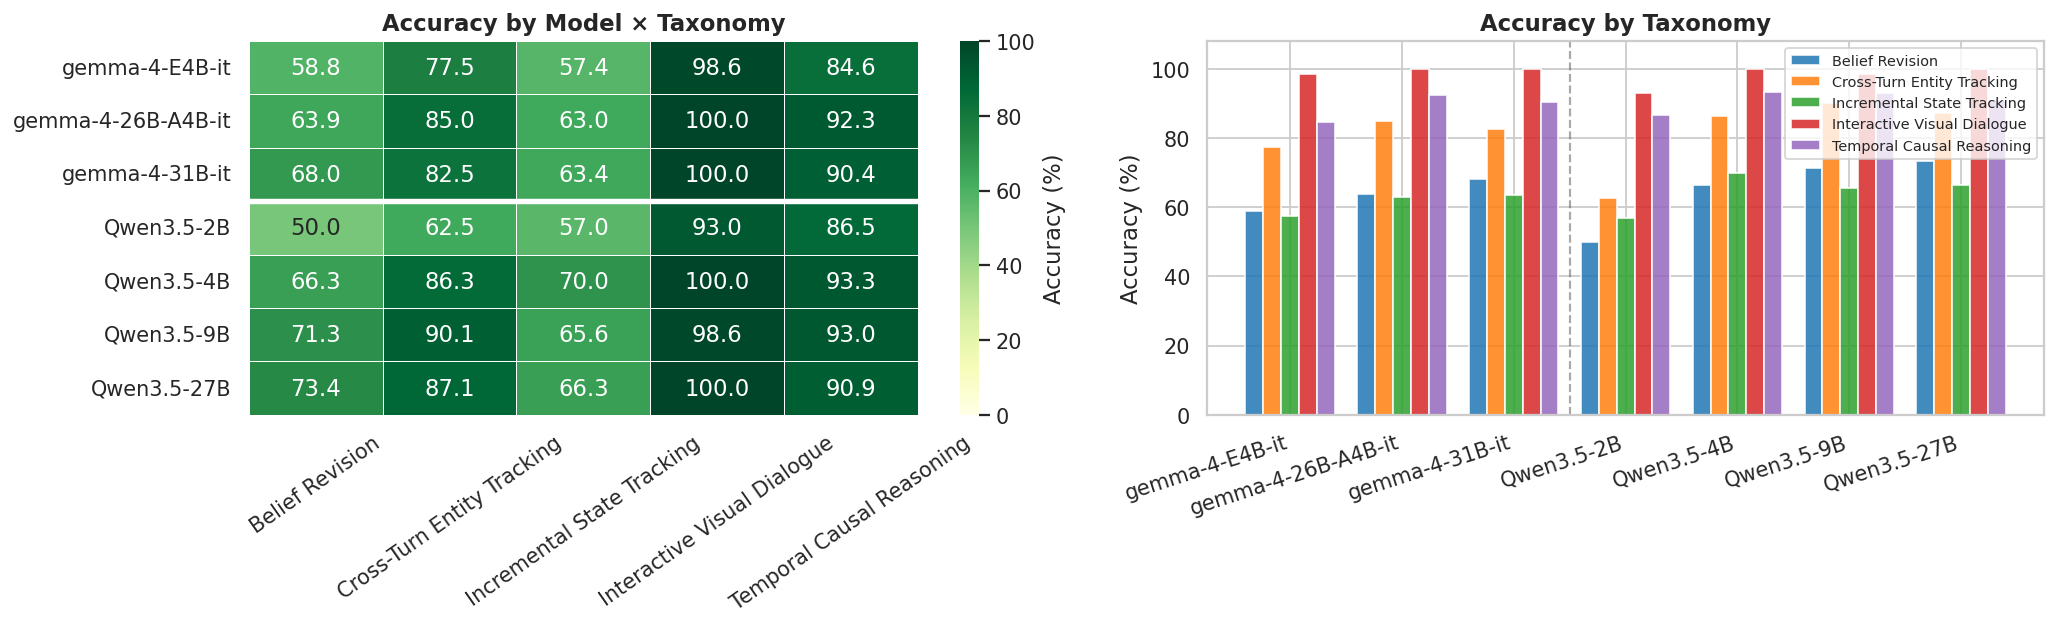

tax_short           Belief Revision  Cross-Turn Entity Tracking  \
model                                                             
gemma-4-E4B-it                 58.8                   77.5        
gemma-4-26B-A4B-it             63.9                   85.0        
gemma-4-31B-it                 68.0                   82.5        
Qwen3.5-2B                     50.0                   62.5        
Qwen3.5-4B                     66.3                   86.3        
Qwen3.5-9B                     71.3                   90.1        
Qwen3.5-27B                    73.4                   87.1        

tax_short           Incremental State Tracking  Interactive Visual Dialogue  \
model                                                                         
gemma-4-E4B-it                       57.4                        98.6         
gemma-4-26B-A4B-it                   63.0                       100.0         
gemma-4-31B-it                       63.4                       100.0         
Q

In [139]:
tax_acc = (df.groupby(['model', 'tax_short'])['correct'].mean() * 100).unstack('tax_short').reindex(MODEL_ORDER)
tax_n   =  df[df['model']==df['model'].iloc[0]].groupby('tax_short').size()
n_tax   = len(tax_acc.columns)

fig, axes = plt.subplots(1, 2, figsize=(6 + n_tax * 2, 5))

ax = axes[0]
col_labels = {c: f'{c}' for c in tax_acc.columns}
sns.heatmap(tax_acc.rename(columns=col_labels), annot=True, fmt='.1f', cmap='YlGn',
            ax=ax, vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Accuracy (%)'})
ax.axhline(3, color='white', linewidth=3)
ax.set_title('Accuracy by Model × Taxonomy', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35)

ax2 = axes[1]
tax_palette = sns.color_palette('tab10', n_tax)
w = 0.8 / n_tax
x = np.arange(len(MODEL_ORDER))
for i, (tax, col) in enumerate(zip(tax_acc.columns, tax_palette)):
    offset = (i - (n_tax - 1) / 2) * w
    ax2.bar(x + offset, tax_acc[tax].values, w, label=tax, color=col, edgecolor='white', alpha=0.85)
ax2.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 108)
ax2.set_title('Accuracy by Taxonomy', fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig_taxonomy.png', bbox_inches='tight')
plt.show()
print(tax_acc.round(1))

## 4b. Taxonomy Sensitivity — Which taxonomy discriminates models most?

Taxonomy Sensitivity (sorted by Std Dev across models)

                             Mean  Std  Range   Min    Max  N models
tax_short                                                           
Cross-Turn Entity Tracking   81.6  9.3   27.6  62.5   90.1         7
Belief Revision              64.5  8.0   23.4  50.0   73.4         7
Incremental State Tracking   63.2  4.7   13.0  57.0   70.0         7
Temporal Causal Reasoning    90.2  3.4    8.7  84.6   93.3         7
Interactive Visual Dialogue  98.6  2.6    7.0  93.0  100.0         7


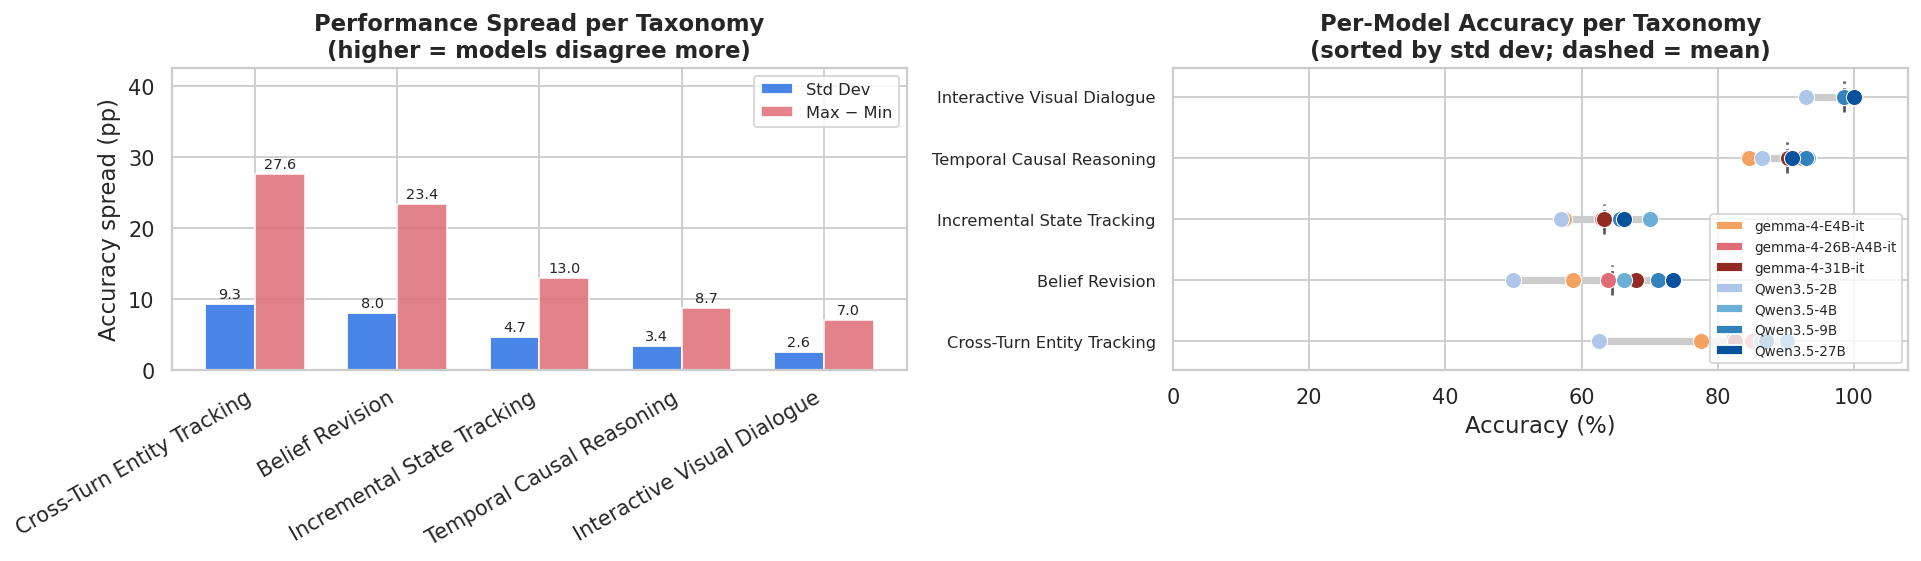

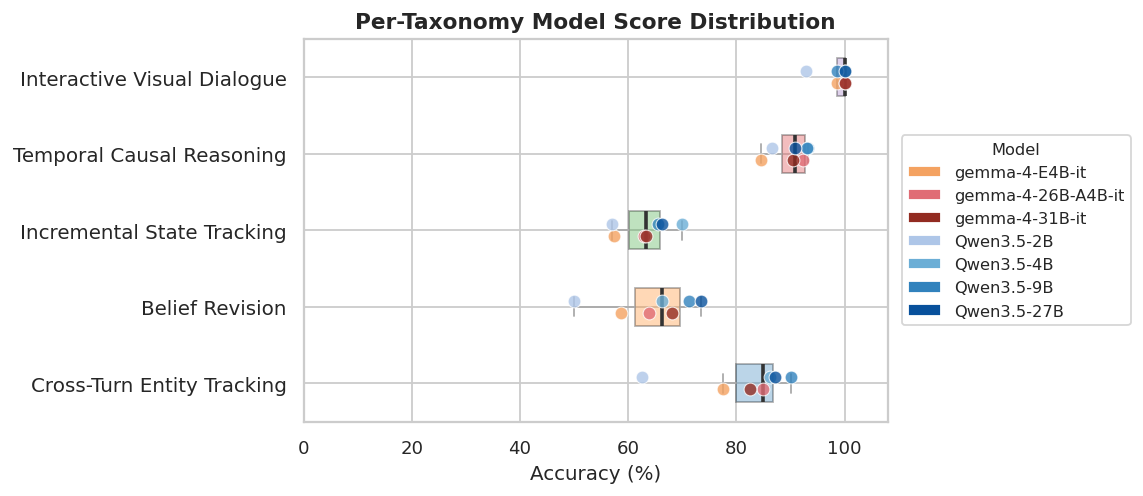

In [159]:
# tax_acc: rows=models, cols=taxonomies (from cell-10)
# Drop taxonomies where fewer than 2 models have data (can't compute spread)
tax_acc_full = tax_acc.dropna(axis=1, thresh=2)

tax_stats = pd.DataFrame({
    'Mean':  tax_acc_full.mean(),
    'Std':   tax_acc_full.std(),
    'Range': tax_acc_full.max() - tax_acc_full.min(),
    'Min':   tax_acc_full.min(),
    'Max':   tax_acc_full.max(),
    'N models': tax_acc_full.notna().sum(),
}).sort_values('Std', ascending=False)

print('Taxonomy Sensitivity (sorted by Std Dev across models)\n')
print(tax_stats.round(1).to_string())

# ── Figure 1: summary bars + dot plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sorted_taxes = tax_stats.index.tolist()
x = np.arange(len(tax_stats))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, tax_stats['Std'],   w, label='Std Dev',   color='#4a86e8', edgecolor='white')
ax.bar(x + w/2, tax_stats['Range'], w, label='Max − Min', color='#e06c75', edgecolor='white', alpha=0.85)
for xi, (std, rng) in enumerate(zip(tax_stats['Std'], tax_stats['Range'])):
    ax.text(xi - w/2, std  + 0.4, f'{std:.1f}',  ha='center', va='bottom', fontsize=8)
    ax.text(xi + w/2, rng  + 0.4, f'{rng:.1f}',  ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(sorted_taxes, rotation=30, ha='right')
ax.set_ylabel('Accuracy spread (pp)')
ax.set_title('Performance Spread per Taxonomy\n(higher = models disagree more)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, tax_stats['Range'].max() + 15)

# Dot plot: one row per taxonomy, horizontal range bar, coloured dots per model
ax2 = axes[1]
y_pos = {tax: i for i, tax in enumerate(sorted_taxes)}
for tax in sorted_taxes:
    yi = y_pos[tax]
    lo, hi = tax_stats.loc[tax, 'Min'], tax_stats.loc[tax, 'Max']
    ax2.hlines(yi, lo, hi, color='#ccc', linewidth=4, zorder=1)
    mu = tax_stats.loc[tax, 'Mean']
    ax2.vlines(mu, yi - 0.25, yi + 0.25, color='#555', linewidth=1.5, zorder=2, linestyle='--')
for model in MODEL_ORDER:
    col = MODEL_COLORS[model]
    for tax in sorted_taxes:
        if tax in tax_acc_full.columns:
            val = tax_acc_full.loc[model, tax]
            if not pd.isna(val):
                ax2.scatter(val, y_pos[tax], color=col, s=80, zorder=3,
                            edgecolors='white', linewidths=0.6)
ax2.set_yticks(range(len(sorted_taxes)))
ax2.set_yticklabels(sorted_taxes, fontsize=9)
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Per-Model Accuracy per Taxonomy\n(sorted by std dev; dashed = mean)', fontweight='bold')
ax2.set_xlim(0, 108)
legend_handles = [Patch(facecolor=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
ax2.legend(handles=legend_handles, fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig('fig_taxonomy_sensitivity.png', bbox_inches='tight')
plt.show()

# ── Figure 2: horizontal box + strip plot ────────────────────────────────────
# Two fixed lanes per row: Gemma family below centre, Qwen above — no per-model variation
FAMILY_YOFFSET = {'Gemma': -0.08, 'Qwen': 0.08}

long = tax_acc_full.reset_index().melt(id_vars='model', var_name='taxonomy', value_name='accuracy')
long = long.dropna(subset=['accuracy'])
long['family'] = long['model'].apply(lambda m: 'Qwen' if 'Qwen' in m else 'Gemma')

fig, ax = plt.subplots(figsize=(9, 4))
palette = {t: c for t, c in zip(sorted_taxes, sns.color_palette('tab10', len(sorted_taxes)))}

for i, tax in enumerate(sorted_taxes):
    vals = long[long['taxonomy'] == tax]['accuracy'].values
    ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True, vert=False,
               boxprops=dict(facecolor=palette[tax], alpha=0.30),
               medianprops=dict(color='#333', linewidth=2),
               whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
               flierprops=dict(marker=''))
    for model in MODEL_ORDER:
        sub = long[(long['taxonomy'] == tax) & (long['model'] == model)]
        if len(sub):
            family = 'Qwen' if 'Qwen' in model else 'Gemma'
            ax.scatter(sub['accuracy'].values[0], i + FAMILY_YOFFSET[family],
                       color=MODEL_COLORS[model], s=50, zorder=4, alpha=0.8,
                       edgecolors='white', linewidths=0.6)

ax.set_yticks(range(len(sorted_taxes)))
ax.set_yticklabels(sorted_taxes, fontsize=11)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.set_xlim(0, 108)
ax.set_title('Per-Taxonomy Model Score Distribution', fontweight='bold', fontsize=12)

legend_handles = [Patch(facecolor=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
ax.legend(handles=legend_handles, fontsize=9, loc='center left',
          bbox_to_anchor=(1.01, 0.5), frameon=True, title='Model', title_fontsize=9)

plt.tight_layout()
plt.savefig('fig_taxonomy_sensitivity_box.png', bbox_inches='tight')
plt.show()

## 5. Accuracy by Question Type

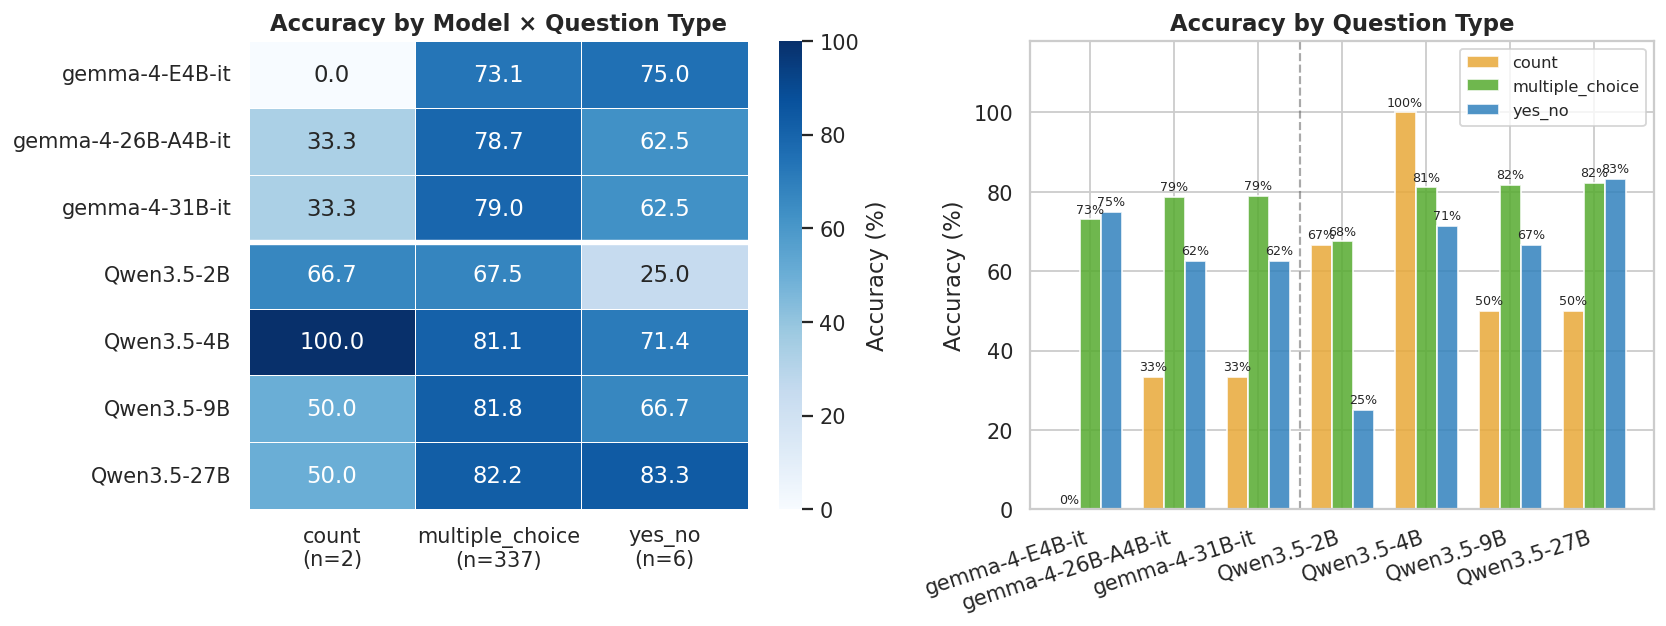

In [141]:
qt_acc = (df.groupby(['model', 'question_type'])['correct'].mean() * 100).unstack('question_type').reindex(MODEL_ORDER)
qt_n   =  df[df['model']==df['model'].iloc[0]].groupby('question_type').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
col_labels = {c: f'{c}\n(n={qt_n.get(c,0)})' for c in qt_acc.columns}
sns.heatmap(qt_acc.rename(columns=col_labels), annot=True, fmt='.1f', cmap='Blues',
            ax=ax, vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Accuracy (%)'})
ax.axhline(3, color='white', linewidth=3)
ax.set_title('Accuracy by Model × Question Type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

ax2 = axes[1]
qt_list = sorted(qt_acc.columns)
qt_colors = ['#e8a838', '#56ab2f', '#3182bd']
x = np.arange(len(MODEL_ORDER)); w = 0.25
for i, (qt, col) in enumerate(zip(qt_list, qt_colors)):
    if qt not in qt_acc.columns: continue
    bars = ax2.bar(x + (i-1)*w, qt_acc[qt].values, w, label=qt, color=col, edgecolor='white', alpha=0.85)
    ax2.bar_label(bars, fmt='%.0f%%', fontsize=7, padding=2)
ax2.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 118)
ax2.set_title('Accuracy by Question Type', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_question_type.png', bbox_inches='tight')
plt.show()

## 6. Scaling Curves — Qwen & Gemma

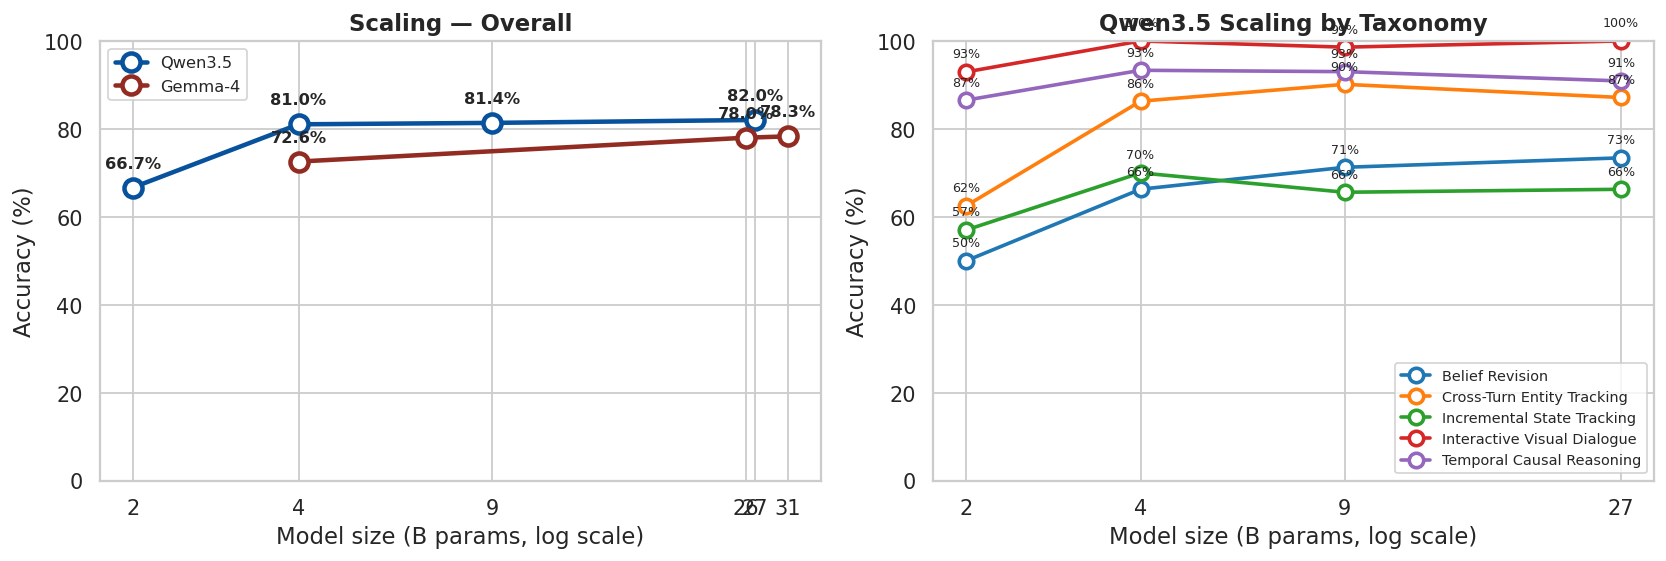

In [142]:
QWEN_SIZES  = {'Qwen3.5-2B': 2, 'Qwen3.5-4B': 4, 'Qwen3.5-9B': 9, 'Qwen3.5-27B': 27}
GEMMA_SIZES = {'gemma-4-E4B-it': 4, 'gemma-4-26B-A4B-it': 26, 'gemma-4-31B-it': 31}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

def plot_scaling(ax, size_map, color, label):
    sub = df[df['model'].isin(size_map)].copy()
    sub['params_b'] = sub['model'].map(size_map)
    overall = sub.groupby('params_b')['correct'].mean().reset_index().sort_values('params_b')
    overall['acc'] = overall['correct'] * 100
    ax.plot(overall['params_b'], overall['acc'], 'o-', color=color, linewidth=2.5,
            markersize=10, markerfacecolor='white', markeredgewidth=2.5, label=label)
    for _, row in overall.iterrows():
        ax.annotate(f"{row['acc']:.1f}%", (row['params_b'], row['acc']),
                    textcoords='offset points', xytext=(0, 11), ha='center', fontsize=9, fontweight='bold')

# Left: both families overall
ax = axes[0]
plot_scaling(ax, QWEN_SIZES,  '#08519c', 'Qwen3.5')
plot_scaling(ax, GEMMA_SIZES, '#922b21', 'Gemma-4')
ax.set_xscale('log'); ax.set_xticks([2,4,9,26,27,31])
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('Model size (B params, log scale)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Scaling — Overall', fontweight='bold'); ax.set_ylim(0, 100); ax.legend(fontsize=9)

# Right: Qwen by taxonomy (all taxonomies present in data)
ax2 = axes[1]
qwen = df[df['model'].isin(QWEN_SIZES)].copy()
qwen['params_b'] = qwen['model'].map(QWEN_SIZES)
qwen_taxes = sorted(qwen['tax_short'].unique())
tax_palette = dict(zip(qwen_taxes, sns.color_palette('tab10', len(qwen_taxes))))
for tax in qwen_taxes:
    g = (qwen[qwen['tax_short']==tax]
         .groupby('params_b')['correct'].mean()
         .reset_index().sort_values('params_b'))
    g['acc'] = g['correct'] * 100
    ax2.plot(g['params_b'], g['acc'], 'o-', label=tax, color=tax_palette[tax],
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    for _, row in g.iterrows():
        ax2.annotate(f"{row['acc']:.0f}%", (row['params_b'], row['acc']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)
ax2.set_xscale('log'); ax2.set_xticks([2,4,9,27])
ax2.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax2.set_xlabel('Model size (B params, log scale)'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Qwen3.5 Scaling by Taxonomy', fontweight='bold')
ax2.set_ylim(0, 100); ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig_scaling.png', bbox_inches='tight')
plt.show()

## 6b. Turn Depth vs. Accuracy

Does performance degrade as the conversation grows longer?
**Turn depth** = number of prior Q&A exchanges the model must track before answering the final question.

In [ ]:
# ── Load turn depth from conversation files ───────────────────────────────────
INPUT_DIR = Path('/projects/bfuj/lzhang49/multimodal-conv-bench/pipeline/output_images')

depth_records = []
for conv_file in sorted(INPUT_DIR.rglob('conversation.jsonl')):
    try:
        rec   = json.loads(conv_file.read_text(encoding='utf-8'))
        turns = rec.get('turns', [])
        meta  = rec.get('_meta', {})
        # Turn depth = assistant turns in stored conversation
        # (last stored turn is always the final user question; last asst turn is withheld in eval)
        n_exchanges = sum(1 for t in turns if t.get('role') == 'assistant')
        depth_records.append({
            'taxonomy':             meta.get('taxonomy', ''),
            'scenario_description': rec.get('scenario_description', ''),
            'n_exchanges':          n_exchanges,
        })
    except Exception:
        pass

depth_df = (pd.DataFrame(depth_records)
            .drop_duplicates(subset=['taxonomy', 'scenario_description']))
print(f'Loaded depth info for {len(depth_df)} conversations')
print(depth_df['n_exchanges'].value_counts().sort_index().rename('# conversations'))

# Join to filtered eval df
df_depth = df.merge(depth_df, on=['taxonomy', 'scenario_description'], how='left')
n_matched = df_depth['n_exchanges'].notna().sum()
print(f'\nMatched {n_matched}/{len(df_depth)} eval rows ({n_matched/len(df_depth)*100:.1f}%)')

# ── Figure: accuracy vs turn depth ───────────────────────────────────────────
d = df_depth.dropna(subset=['n_exchanges']).copy()
d['n_exchanges'] = d['n_exchanges'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overall accuracy per depth (bar + item count)
depth_acc = (d.groupby('n_exchanges')['correct']
             .agg(accuracy='mean', n='count')
             .reset_index()
             .assign(accuracy=lambda x: x['accuracy'] * 100))

ax = axes[0]
bars = ax.bar(depth_acc['n_exchanges'], depth_acc['accuracy'],
              color='#4a86e8', edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars, depth_acc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row['accuracy']:.1f}%\n(n={int(row['n'])})",
            ha='center', va='bottom', fontsize=8.5)
ax.set_xlabel('Number of prior Q&A exchanges (turn depth)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs. Turn Depth\n(all models combined)', fontweight='bold')
ax.set_ylim(0, 108)
ax.set_xticks(sorted(d['n_exchanges'].unique()))

# Right: per-taxonomy line plot
ax2 = axes[1]
depth_tax = (d.groupby(['n_exchanges', 'tax_short'])['correct']
             .mean() * 100).unstack('tax_short')
tax_list = sorted(depth_tax.columns)
tax_pal  = dict(zip(tax_list, sns.color_palette('tab10', len(tax_list))))

for tax in tax_list:
    col = tax_pal[tax]
    series = depth_tax[tax].dropna()
    if len(series) < 2:
        ax2.scatter(series.index, series.values, color=col, s=60,
                    label=f'{tax} (n={len(series)})', zorder=4)
    else:
        ax2.plot(series.index, series.values, 'o-', color=col, label=tax,
                 linewidth=2, markersize=7, markerfacecolor='white', markeredgewidth=2)
        for xi, yi in zip(series.index, series.values):
            ax2.annotate(f'{yi:.0f}%', (xi, yi),
                         textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=7.5)

ax2.set_xlabel('Number of prior Q&A exchanges (turn depth)')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs. Turn Depth by Taxonomy', fontweight='bold')
ax2.set_ylim(0, 108)
ax2.set_xticks(sorted(d['n_exchanges'].unique()))
ax2.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('fig_turn_depth.png', bbox_inches='tight')
plt.show()

# ── Per-model trend table ─────────────────────────────────────────────────────
print('\nAccuracy by (model × turn depth):')
print((d.groupby(['model', 'n_exchanges'])['correct'].mean() * 100)
      .unstack('n_exchanges').reindex(MODEL_ORDER).round(1).to_string())

## 7. Item-Level Difficulty

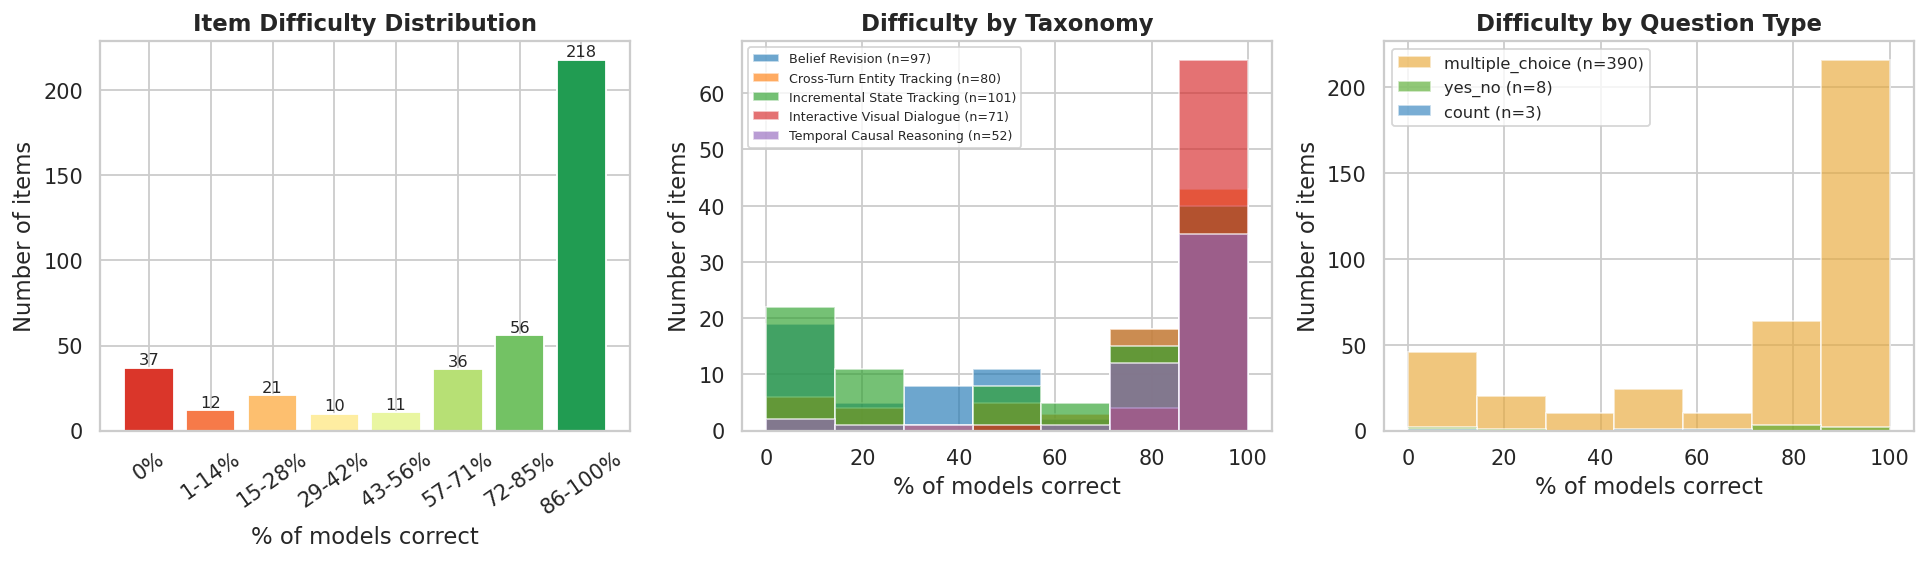

All models correct : 218 (54.4%)
No model correct   :  37 (9.2%)
Mixed              : 146 (36.4%)
Mean item accuracy : 75.7%


In [143]:
item_acc  = df.groupby('idx')['correct'].mean() * 100
# Build item_meta from ALL models (first non-null per idx) so items only
# evaluated by a subset of models still get proper taxonomy/question metadata.
item_meta = (
    df.sort_values('model')
    .groupby('idx')[['taxonomy','tax_short','question_type','scenario_title','question','ground_truth']]
    .first()
)
item_df = item_meta.join(item_acc.rename('pct_correct'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
bins = [0, 1, 15, 29, 43, 57, 72, 86, 100.01]
hist_vals, _ = np.histogram(item_df['pct_correct'], bins=bins)
labels = ['0%','1-14%','15-28%','29-42%','43-56%','57-71%','72-85%','86-100%']
palette = sns.color_palette('RdYlGn', len(labels))
bars = ax.bar(labels, hist_vals, color=palette, edgecolor='white')
ax.bar_label(bars, fontsize=9)
ax.set_xlabel('% of models correct'); ax.set_ylabel('Number of items')
ax.set_title('Item Difficulty Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=35)

ax2 = axes[1]
all_taxes = sorted(item_df['tax_short'].unique())
tax_palette = dict(zip(all_taxes, sns.color_palette('tab10', len(all_taxes))))
for tax in all_taxes:
    sub = item_df[item_df['tax_short']==tax]['pct_correct']
    ax2.hist(sub, bins=7, range=(0,100), alpha=0.65, color=tax_palette[tax],
             label=f'{tax} (n={len(sub)})', edgecolor='white')
ax2.set_xlabel('% of models correct'); ax2.set_ylabel('Number of items')
ax2.set_title('Difficulty by Taxonomy', fontweight='bold')
ax2.legend(fontsize=7)

ax3 = axes[2]
for qt, col in [('multiple_choice','#e8a838'),('yes_no','#56ab2f'),('count','#3182bd')]:
    sub = item_df[item_df['question_type']==qt]['pct_correct']
    if len(sub):
        ax3.hist(sub, bins=7, range=(0,100), alpha=0.65, color=col, label=f'{qt} (n={len(sub)})', edgecolor='white')
ax3.set_xlabel('% of models correct'); ax3.set_ylabel('Number of items')
ax3.set_title('Difficulty by Question Type', fontweight='bold'); ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_item_difficulty.png', bbox_inches='tight')
plt.show()

easy = item_df[item_df['pct_correct'] == 100]
hard = item_df[item_df['pct_correct'] == 0]
med  = item_df[(item_df['pct_correct'] > 0) & (item_df['pct_correct'] < 100)]
print(f'All models correct : {len(easy):3d} ({len(easy)/len(item_df)*100:.1f}%)')
print(f'No model correct   : {len(hard):3d} ({len(hard)/len(item_df)*100:.1f}%)')
print(f'Mixed              : {len(med):3d} ({len(med)/len(item_df)*100:.1f}%)')
print(f'Mean item accuracy : {item_df["pct_correct"].mean():.1f}%')

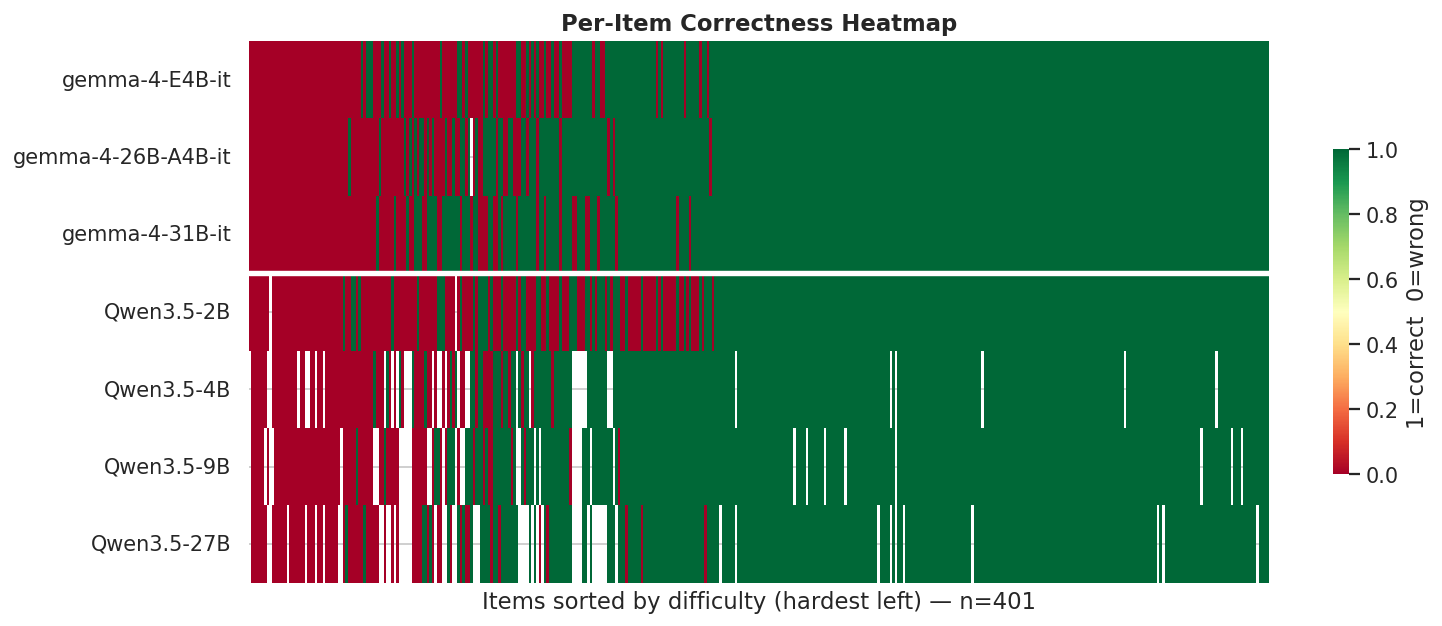

In [144]:
# Per-item heatmap
item_model = df.pivot_table(index='idx', columns='model', values='correct')[MODEL_ORDER]
item_model = item_model.loc[item_model.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(item_model.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=False, yticklabels=True, linewidths=0,
            cbar_kws={'label': '1=correct  0=wrong', 'shrink': 0.6})
# Family separator line
ax.axhline(3, color='white', linewidth=3)
ax.set_xlabel(f'Items sorted by difficulty (hardest left) — n={len(item_model)}')
ax.set_ylabel('')
ax.set_title('Per-Item Correctness Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_item_heatmap.png', bbox_inches='tight')
plt.show()

In [145]:
print('=== Items no model solved ===\n')
for idx, row in hard.iterrows():
    print(f'  idx={idx}  [{row["tax_short"]}] [{row["question_type"]}]  GT={row["ground_truth"]!r}')
    print(f'  Title: {row["scenario_title"]}')
    print(f'  Q: {row["question"][:160]}')
    print()

=== Items no model solved ===

  idx=4  [Belief Revision] [multiple_choice]  GT='b'
  Title: Identifying a mineral sample
  Q: What is the correct identification of the mineral sample?

B) Quartz
A) Diamond
C) Topaz
D) Sapphire

  idx=15  [Belief Revision] [multiple_choice]  GT='b'
  Title: Identifying a mineral in a rock sample
  Q: What mineral is the crystal in this rock sample?

B) Quartz with titanium impurities
A) Diamond
C) Zircon
D) Tourmaline

  idx=18  [Belief Revision] [multiple_choice]  GT='b'
  Title: Identifying a marine species
  Q: What species is the marine creature shown in the images?

B) Cuttlefish
A) Ray
C) Squid
D) Octopus

  idx=21  [Belief Revision] [multiple_choice]  GT='c'
  Title: Assessing crop health in a drought-affected field
  Q: What is the primary cause of the brown patches in the field?

C) Localized pest infestation
A) Severe drought with uniform soil dehydration
B) Soil erosion from

  idx=25  [Belief Revision] [multiple_choice]  GT='b'
  Title: Ide

## 8. Cross-Model Agreement

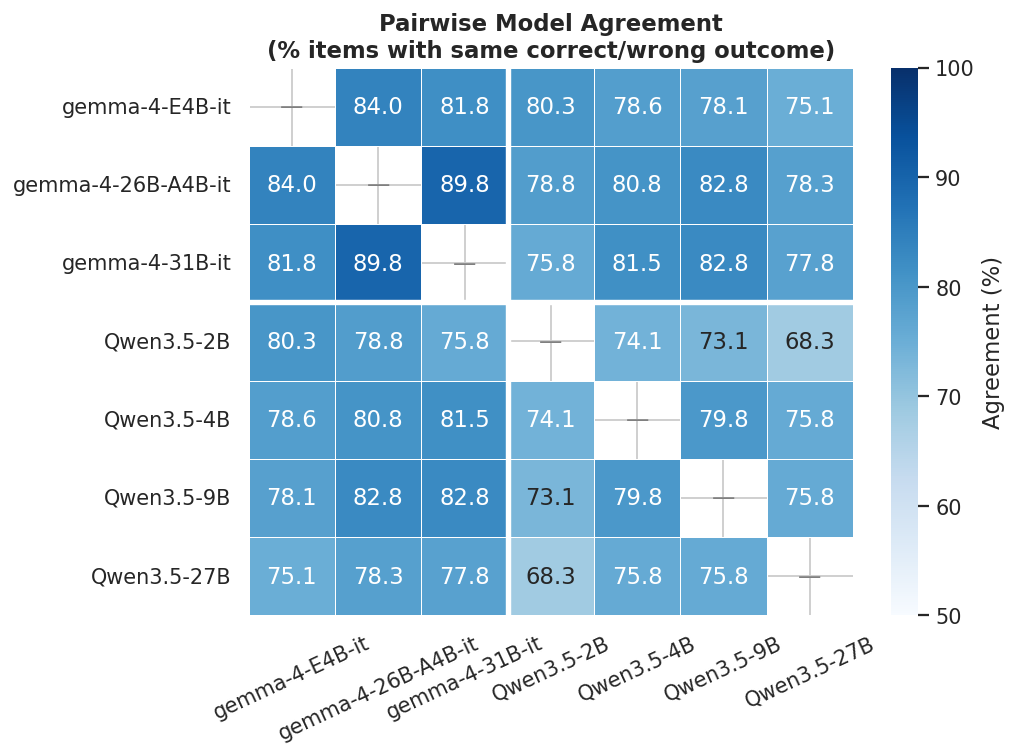

In [146]:
correct_matrix = df.pivot_table(index='idx', columns='model', values='correct')[MODEL_ORDER]

n = len(MODEL_ORDER)
agree = np.zeros((n, n))
for i, m1 in enumerate(MODEL_ORDER):
    for j, m2 in enumerate(MODEL_ORDER):
        agree[i, j] = (correct_matrix[m1] == correct_matrix[m2]).mean() * 100
agree_df = pd.DataFrame(agree, index=MODEL_ORDER, columns=MODEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(n, dtype=bool)
sns.heatmap(agree_df, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            mask=mask, vmin=50, vmax=100, linewidths=0.5,
            cbar_kws={'label': 'Agreement (%)'})
for i in range(n):
    ax.text(i+0.5, i+0.5, '—', ha='center', va='center', fontsize=13, color='gray')
# Family separator
ax.axhline(3, color='white', linewidth=3); ax.axvline(3, color='white', linewidth=3)
ax.set_title('Pairwise Model Agreement\n(% items with same correct/wrong outcome)', fontweight='bold')
ax.tick_params(axis='x', rotation=25); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_agreement.png', bbox_inches='tight')
plt.show()

In [147]:
item_std = correct_matrix.std(axis=1).rename('std')
controversial = item_std.nlargest(10).to_frame().join(item_meta)

# Pivot predictions so we can show what each model actually answered
pred_matrix = df.pivot_table(index='idx', columns='model', values='prediction', aggfunc='first')[MODEL_ORDER]

short = {m: m.replace('gemma-4-','G-').replace('Qwen3.5-','Q-') for m in MODEL_ORDER}

print('=== Most Controversial Items (models disagree most) ===\n')
for idx, row in controversial.iterrows():
    question = str(row.get("question") or '')
    print(f'idx={idx}  [{row["tax_short"]}] [{row["question_type"]}]  GT={row["ground_truth"]!r}  std={row["std"]:.2f}')
    print(f'  Title  : {row["scenario_title"]}')
    print(f'  Q      : {question[:150]}')
    for m in MODEL_ORDER:
        pred = pred_matrix.loc[idx, m]
        correct = correct_matrix.loc[idx, m]
        mark = '✓' if correct == 1 else '✗'
        print(f'  {mark} {short[m]:15s} pred={str(pred)!r}')
    print()

=== Most Controversial Items (models disagree most) ===

idx=213  [Incremental State Tracking] [multiple_choice]  GT='c'  std=0.58
  Title  : Monitoring illegal deforestation in the Amazon
  Q      : What is the total area of deforestation shown in the sequence?

C) 7.7km²
A) 6.8km²
B) 5.5km²
D) 8.2km²
  ✗ G-E4B-it        pred='a'
  ✗ G-26B-A4B-it    pred='a'
  ✓ G-31B-it        pred='c'
  ✗ Q-2B            pred='nan'
  ✓ Q-4B            pred='c'
  ✗ Q-9B            pred='nan'
  ✗ Q-27B           pred='nan'

idx=32  [Belief Revision] [multiple_choice]  GT='b'  std=0.55
  Title  : Identifying a marine organism
  Q      : What marine invertebrate is depicted in the initial image?

B) Bryozoan colony
A) Siphonophore
C) Sea anemone
D) Ctenophore
  ✗ G-E4B-it        pred='d'
  ✓ G-26B-A4B-it    pred='b'
  ✓ G-31B-it        pred='b'
  ✗ Q-2B            pred='a'
  ✗ Q-4B            pred='nan'
  ✗ Q-9B            pred='a'
  ✗ Q-27B           pred='nan'

idx=50  [Belief Revision] [multiple_choi

## 9. Model Family Comparison — Gemma vs Qwen

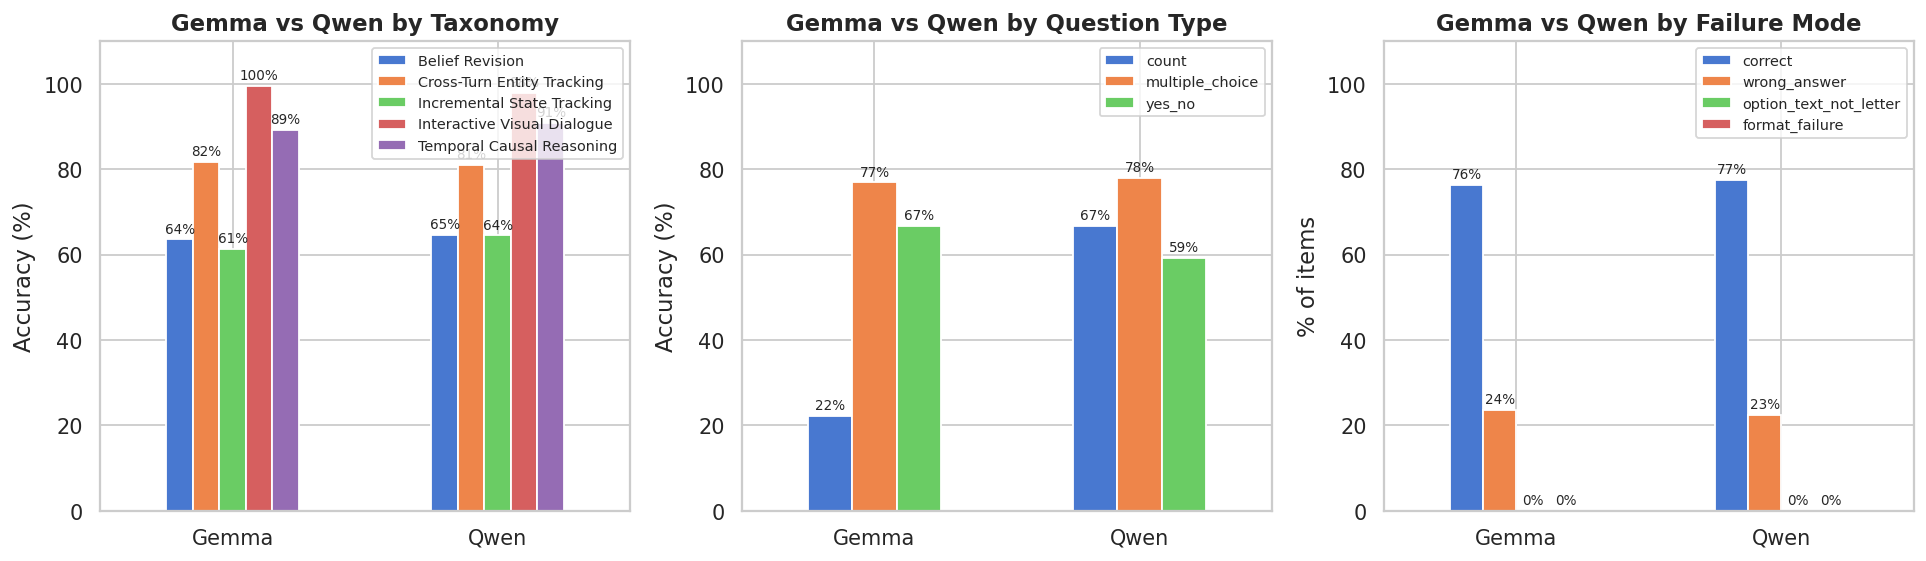

In [148]:
MODES = ['correct', 'wrong_answer', 'option_text_not_letter', 'format_failure']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, dim, title, ylabel in zip(
    axes,
    ['tax_short', 'question_type', 'failure_mode'],
    ['by Taxonomy', 'by Question Type', 'by Failure Mode'],
    ['Accuracy (%)', 'Accuracy (%)', '% of items'],
):
    if dim == 'failure_mode':
        grp = (df.groupby(['family', dim]).size() /
               df.groupby('family').size()).unstack(dim).fillna(0) * 100
        grp = grp.reindex(columns=MODES, fill_value=0)
    else:
        grp = (df.groupby(['family', dim])['correct'].mean() * 100).unstack(dim)
    grp.plot(kind='bar', ax=ax, width=0.5, edgecolor='white')
    ax.set_title(f'Gemma vs Qwen {title}', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(ylabel)
    ax.set_ylim(0, 110); ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.0f%%', fontsize=7.5, padding=2)

plt.tight_layout()
plt.savefig('fig_family_comparison.png', bbox_inches='tight')
plt.show()

## 10. Full Summary Table

In [149]:
def pct_str(sub):
    n = len(sub); c = int(sub['correct'].sum())
    return f'{c/n*100:.1f}% ({c}/{n})' if n else 'N/A'

all_taxes = sorted(df['tax_short'].unique())

rows = []
for model in MODEL_ORDER:
    m     = df[df['model'] == model]         # accuracy denominator: parseable only
    m_all = df_all[df_all['model'] == model] # failure-mode denominator: all items
    fm = m_all['failure_mode'].value_counts(normalize=True).mul(100)
    row = {
        'Model':     model,
        'Family':    'Gemma' if 'gemma' in model else 'Qwen',
        'Overall':   pct_str(m),
        'MC':        pct_str(m[m['question_type']=='multiple_choice']),
        'Yes/No':    pct_str(m[m['question_type']=='yes_no']),
        'Count':     pct_str(m[m['question_type']=='count']),
    }
    for tax in all_taxes:
        row[tax] = pct_str(m[m['tax_short']==tax])
    row['No-box%']   = f"{fm.get('format_failure',0):.1f}%"
    row['Opt-text%'] = f"{fm.get('option_text_not_letter',0):.1f}%"
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model')
pd.set_option('display.max_colwidth', 22)
summary

,Family,Overall,MC,Yes/No,Count,Belief Revision,Cross-Turn Entity Tracking,Incremental State Tracking,Interactive Visual Dialogue,Temporal Causal Reasoning,No-box%,Opt-text%
Model,,,,,,,,,,,,
gemma-4-E4B-it,Gemma,72.6% (291/401),73.1% (285/390),75.0% (6/8),0.0% (0/3),58.8% (57/97),77.5% (62/80),57.4% (58/101),98.6% (70/71),84.6% (44/52),0.0%,0.0%
gemma-4-26B-A4B-it,Gemma,78.0% (312/400),78.7% (306/389),62.5% (5/8),33.3% (1/3),63.9% (62/97),85.0% (68/80),63.0% (63/100),100.0% (71/71),92.3% (48/52),0.2%,0.0%
gemma-4-31B-it,Gemma,78.3% (314/401),79.0% (308/390),62.5% (5/8),33.3% (1/3),68.0% (66/97),82.5% (66/80),63.4% (64/101),100.0% (71/71),90.4% (47/52),0.0%,0.0%
Qwen3.5-2B,Qwen,66.7% (266/399),67.5% (262/388),25.0% (2/8),66.7% (2/3),50.0% (48/96),62.5% (50/80),57.0% (57/100),93.0% (66/71),86.5% (45/52),0.5%,0.0%
Qwen3.5-4B,Qwen,81.0% (295/364),81.1% (288/355),71.4% (5/7),100.0% (2/2),66.3% (57/86),86.3% (63/73),70.0% (63/90),100.0% (70/70),93.3% (42/45),9.2%,0.0%
Qwen3.5-9B,Qwen,81.4% (297/365),81.8% (292/357),66.7% (4/6),50.0% (1/2),71.3% (62/87),90.1% (64/71),65.6% (61/93),98.6% (70/71),93.0% (40/43),9.0%,0.0%
Qwen3.5-27B,Qwen,82.0% (283/345),82.2% (277/337),83.3% (5/6),50.0% (1/2),73.4% (58/79),87.1% (61/70),66.3% (55/83),100.0% (69/69),90.9% (40/44),14.0%,0.0%


---
## [Optional] Text-Only Baseline vs Image Eval — Qwen3.5-27B

Loads all `*Qwen3.5-27B*.jsonl` files from the eval results directory,
merges them across taxonomies, and compares text+image vs text-only mode item-by-item.
**This cell is self-contained — drop it without affecting any other section.**

Multimodal (text+image): 4 file(s) -> 399 items after merge + filter
Text-only baseline:      1 file(s) -> 399 items after merge + filter
  Multimodal taxonomies: ['belief_revision', 'cross_turn_entity_tracking', 'incremental_state_tracking', 'interactive_visual_dialogue', 'temporal_causal_reasoning']
  Text-only  taxonomies: ['belief_revision', 'cross_turn_entity_tracking', 'incremental_state_tracking', 'interactive_visual_dialogue', 'temporal_causal_reasoning']

Matched items (in both evals): 399

Outcome breakdown (text+image vs text-only — Qwen3.5-27B):
  same outcome        : 305 ( 76.4%)
  only multimodal     :  37 (  9.3%)
  other               :  57 ( 14.3%)


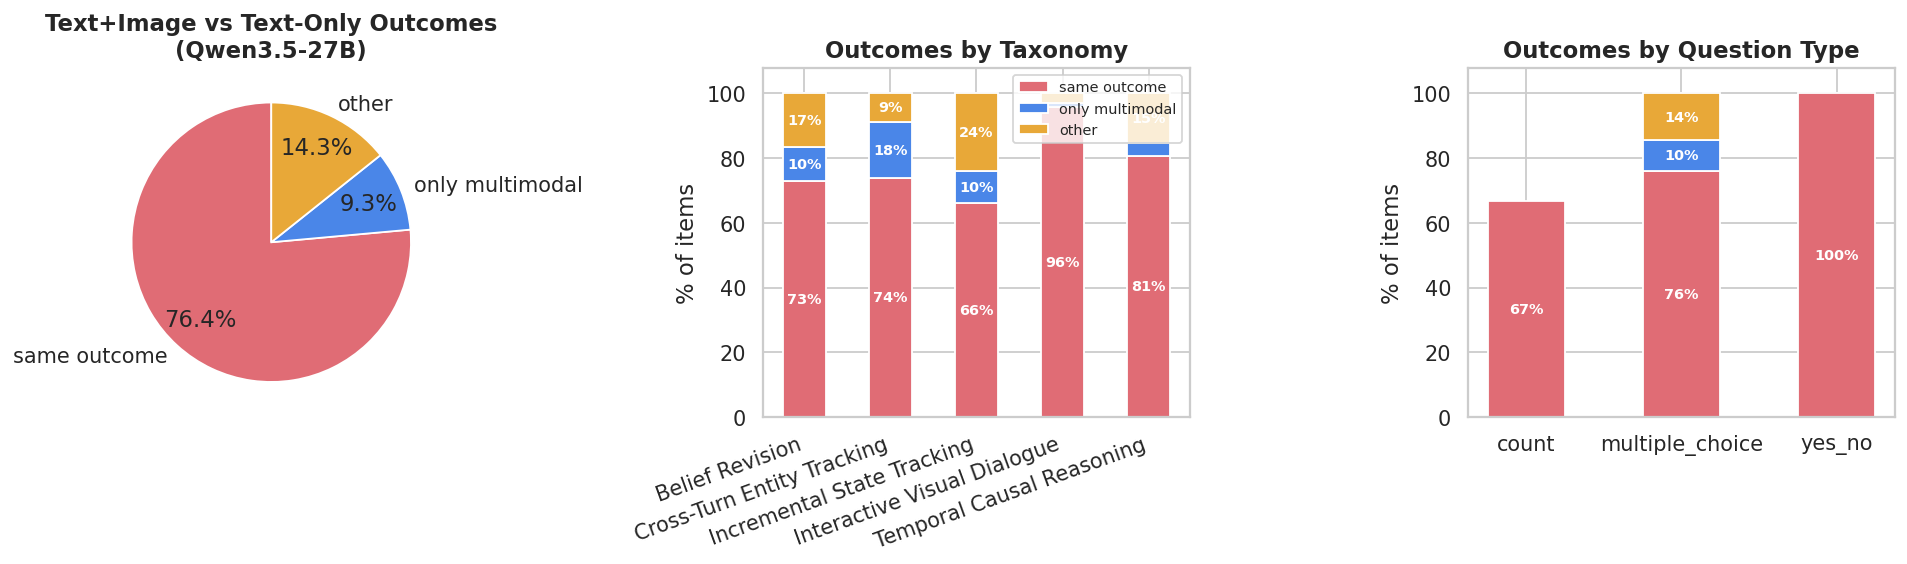

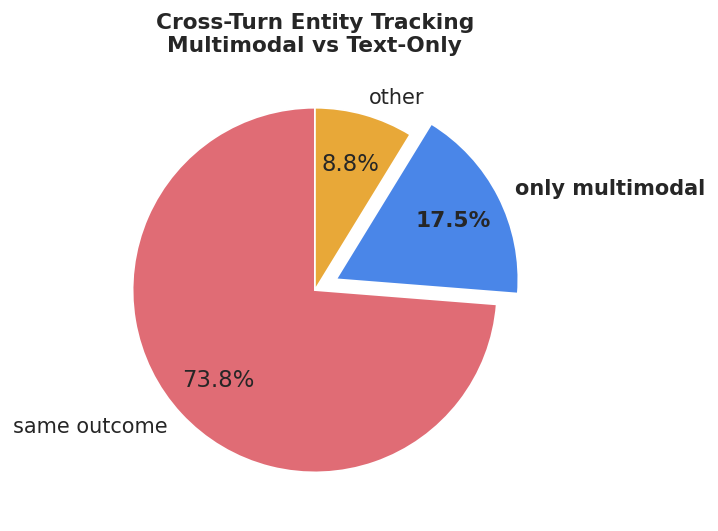


=== Text+Image HELPED (multimodal correct, text-only wrong) (37 items) ===
  [Cross-Turn Entity Tracking] [multiple_choice]  GT='b'
  Q: Which object is currently sitting behind the leather books? A) The brass compass B) The silver pocket watch C) Both items D) Neither item

  [Temporal Causal Reasoning] [multiple_choice]  GT='b'
  Q: I need to know for the insurance claim: did the original impact that caused the bend also cause the crack, or did my attempt to straighten the pivot c

  [Temporal Causal Reasoning] [multiple_choice]  GT='b'
  Q: Based on the visual evidence in these steps, did the diagonal tear happen before or after the paper was folded into the rectangular shape with the ver

  [Cross-Turn Entity Tracking] [multiple_choice]  GT='b'
  Q: Based on the whole process we've seen, which frame is the original one? A) The frame on the left, next to the new red brick wall. B) The frame on the 

  [Cross-Turn Entity Tracking] [multiple_choice]  GT='c'
  Q: I need to know exactl

In [170]:
# ── Locate all Qwen3.5-27B result files ───────────────────────────────────────
_all_27b  = sorted(EVAL_DIR.glob('*Qwen3.5-27B*.jsonl'))
_mm_files = [f for f in _all_27b if 'textonly' not in f.name]   # text+image (multimodal)
_to_files = [f for f in _all_27b if 'textonly'     in f.name]   # text-only baseline

if not _to_files:
    print('Text-only baseline results not found — run eval_textonly_baseline.sh first.')
    print(f'  looked for: {EVAL_DIR}/*Qwen3.5-27B*textonly*.jsonl')
elif not _mm_files:
    print('Multimodal (text+image) eval results not found for Qwen3.5-27B.')
else:
    def _load_merge(files):
        """Load files, dedup by (taxonomy, scenario_description) keeping latest run."""
        frames = []
        for f in files:
            rows = [json.loads(l) for l in f.open() if l.strip()]
            if not rows:
                continue
            d = pd.DataFrame(rows)
            m = re.search(r'_(\d{8}_\d{6})\.jsonl$', f.name)
            d['_file_ts'] = m.group(1) if m else ''
            frames.append(d)
        if not frames:
            return None
        combined = (pd.concat(frames, ignore_index=True)
                    .sort_values('_file_ts')
                    .drop_duplicates(subset=['taxonomy', 'scenario_description'], keep='last')
                    .drop(columns=['_file_ts'])
                    .reset_index(drop=True))
        combined['has_options'] = combined['question'].apply(
            lambda q: bool(MC_OPTION_RE.search(q or '')))
        return combined[combined['has_options'] | (combined['question_type'] != 'multiple_choice')].copy()

    _mm_df = _load_merge(_mm_files)
    _to_df = _load_merge(_to_files)

    print(f'Multimodal (text+image): {len(_mm_files)} file(s) -> {len(_mm_df)} items after merge + filter')
    print(f'Text-only baseline:      {len(_to_files)} file(s) -> {len(_to_df)} items after merge + filter')
    print(f'  Multimodal taxonomies: {sorted(_mm_df["taxonomy"].unique())}')
    print(f'  Text-only  taxonomies: {sorted(_to_df["taxonomy"].unique())}')

    # Join on (taxonomy, scenario_description) — content-based, robust across runs
    _merged = (
        _mm_df[['taxonomy','scenario_description','question_type','ground_truth','question','correct']]
        .merge(
            _to_df[['taxonomy','scenario_description','correct']].rename(columns={'correct':'correct_to'}),
            on=['taxonomy', 'scenario_description'], how='inner'
        )
        .rename(columns={'correct': 'correct_mm'})
    )
    _merged['tax_short'] = _merged['taxonomy'].map(TAX_NAMES).fillna(_merged['taxonomy'])
    print(f'\nMatched items (in both evals): {len(_merged)}')

    if len(_merged) == 0:
        print('No overlap — check that both evals cover at least one common taxonomy.')
    else:
        def _cat(row):
            mm, to = row['correct_mm'], row['correct_to']
            if mm and to:      return 'same outcome'
            if mm and not to:  return 'only multimodal'
            if not mm and to:  return 'other'
            return 'same outcome'
        _merged['outcome'] = _merged.apply(_cat, axis=1)

        _CAT_COLORS = {'only multimodal': '#4a86e8',
                       'other':  '#e8a838',
                       'same outcome':      '#e06c75'}
        _cats = ['same outcome', 'only multimodal', 'other']

        _vc = _merged['outcome'].value_counts().reindex(_cats, fill_value=0)
        _n  = len(_merged)
        print('\nOutcome breakdown (text+image vs text-only — Qwen3.5-27B):')
        for cat, cnt in _vc.items():
            print(f'  {cat:20s}: {cnt:3d} ({cnt/_n*100:5.1f}%)')

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

        ax = axes[0]
        ax.pie(_vc.values, labels=_cats, colors=[_CAT_COLORS[c] for c in _cats],
               autopct='%1.1f%%', startangle=90, pctdistance=0.75)
        ax.set_title('Text+Image vs Text-Only Outcomes\n(Qwen3.5-27B)', fontweight='bold')

        ax2 = axes[1]
        _tax_out = (_merged.groupby(['tax_short', 'outcome']).size()
                    .unstack('outcome').reindex(columns=_cats, fill_value=0))
        _tax_pct = _tax_out.div(_tax_out.sum(axis=1), axis=0) * 100
        _bot = np.zeros(len(_tax_pct)); _x = np.arange(len(_tax_pct))
        for cat in _cats:
            _v = _tax_pct[cat].values
            ax2.bar(_x, _v, bottom=_bot, label=cat, color=_CAT_COLORS[cat], width=0.5, edgecolor='white')
            for xi, (v, b) in enumerate(zip(_v, _bot)):
                if v > 6:
                    ax2.text(xi, b+v/2, f'{v:.0f}%', ha='center', va='center',
                             fontsize=8, color='white', fontweight='bold')
            _bot += _v
        ax2.set_xticks(_x); ax2.set_xticklabels(_tax_pct.index, rotation=20, ha='right')
        ax2.set_ylabel('% of items'); ax2.set_ylim(0, 108)
        ax2.set_title('Outcomes by Taxonomy', fontweight='bold')
        ax2.legend(fontsize=8, loc='upper right')

        ax3 = axes[2]
        _qt_out = (_merged.groupby(['question_type', 'outcome']).size()
                   .unstack('outcome').reindex(columns=_cats, fill_value=0))
        _qt_pct = _qt_out.div(_qt_out.sum(axis=1), axis=0) * 100
        _bot = np.zeros(len(_qt_pct)); _x2 = np.arange(len(_qt_pct))
        for cat in _cats:
            _v = _qt_pct[cat].values
            ax3.bar(_x2, _v, bottom=_bot, label=cat, color=_CAT_COLORS[cat], width=0.5, edgecolor='white')
            for xi, (v, b) in enumerate(zip(_v, _bot)):
                if v > 6:
                    ax3.text(xi, b+v/2, f'{v:.0f}%', ha='center', va='center',
                             fontsize=8, color='white', fontweight='bold')
            _bot += _v
        ax3.set_xticks(_x2); ax3.set_xticklabels(_qt_pct.index)
        ax3.set_ylabel('% of items'); ax3.set_ylim(0, 108)
        ax3.set_title('Outcomes by Question Type', fontweight='bold')

        plt.tight_layout()
        plt.savefig('fig_textonly_baseline.png', bbox_inches='tight')
        plt.show()

        # ── Cross-Turn Entity Tracking zoom-in pie ─────────────────────────────
        _ctet = _merged[_merged['taxonomy'] == 'cross_turn_entity_tracking']
        if len(_ctet) > 0:
            _ctet_vc = _ctet['outcome'].value_counts().reindex(_cats, fill_value=0)
            _ctet_n  = len(_ctet)
            _explode = [0.13 if c == 'only multimodal' else 0 for c in _cats]
            fig2, ax4 = plt.subplots(figsize=(5.5, 5.5))
            wedges, texts, autotexts = ax4.pie(
                _ctet_vc.values,
                labels=_cats,
                colors=[_CAT_COLORS[c] for c in _cats],
                explode=_explode,
                autopct='%1.1f%%',
                startangle=90,
                pctdistance=0.72,
            )
            for i, cat in enumerate(_cats):
                if cat == 'only multimodal':
                    texts[i].set_fontweight('bold')
                    autotexts[i].set_fontweight('bold')
                    autotexts[i].set_fontsize(12)
            ax4.set_title(
                f'Cross-Turn Entity Tracking\nMultimodal vs Text-Only',
                fontweight='bold', fontsize=12,
            )
            plt.tight_layout()
            plt.savefig('fig_ctet_pie.png', bbox_inches='tight')
            plt.show()

        for outcome, label in [
                ('only multimodal', 'Text+Image HELPED (multimodal correct, text-only wrong)'),
                ('other',  'Text+Image HURT   (text-only correct, multimodal wrong)')]:
            _sub = _merged[_merged['outcome'] == outcome]
            print(f'\n=== {label} ({len(_sub)} items) ===')
            for _, r in _sub.head(5).iterrows():
                q = str(r.get('question') or '')
                print(f'  [{r["tax_short"]}] [{r["question_type"]}]  GT={r["ground_truth"]!r}')
                print(f'  Q: {q[:150]}')
                print()
